In [234]:
import sys

print(sys.executable)

/Users/preciousajilore/Documents/GitHub/torchmtlr/survivalenv/bin/python


In [235]:
import pandas as pd
import numpy as np
import seaborn as sns
import wandb
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import StratifiedKFold, cross_validate

wandb.login()   # will prompt for your API key if you haven’t saved it
run = wandb.init(
    project="UroLOGIC",
    name="model-comparison",
    config={
        "test_size": 0.2,
        "smote_k": 4,
        "threshold": 0.3,
    }
)
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier


wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


In [236]:
#Load data
df = pd.read_csv('/Users/preciousajilore/Documents/GitHub/torchmtlr/notebooks/preop.csv')

In [237]:
#Drop the rows where failure is equal to 2
df = df[df['failure'] != 2]

In [238]:
#Sanityy check lol
df['failure'].unique()

array([0., 1.])

In [239]:
df.columns

Index(['stxlocation', 'distal', 'penile', 'stxetiology', 'stxlength',
       '#strictures', 'charlsons', 'cormorbidity', 'diabetes', 'copd',
       'smoker', 'bmi35+', 'prevprocedure', '#prevprocedures', 'cysto', 'open',
       'ordate', 'urine', 'stx_length_1', 'stx_length_2', 'stxetiology_0',
       'stxetiology_1', 'stxetiology_2', 'stxetiology_3', 'stxetiology_4',
       'stxetiology_5', 'stxetiology_6', 'stxlocation_0', 'stxlocation_1',
       'stxlocation_2', 'stxlocation_3', 'stxlocation_4', 'stxlocation_5',
       'stxlocation_6', 'stx_length_1.1', 'stx_length_2.1', 'cysto_0.0',
       'cysto_1.0', 'cysto_2.0', 'cysto_3.0', 'abx', 'erectilepre', 'uti',
       'failure', 'time_to_event'],
      dtype='object')

In [240]:
#Drop columns that we wont use for prediction

"""

Index(['dob(yyyy-mm-dd)', 'dateofsurgery', 'monthsurg', 'age:<50=0;>=50=1',
       'stxlocation', 'distal', 'penile', '#strictures', 'charlsons',
       'cormorbidity', 'diabetes', 'copd', 'smoker', 'bmi35+', 'bmiexact',
       'prevprocedure', '#prevprocedures', 'cysto', 'open', 'ordate', 'urine',
       'abx', 'erectilepre', 'uti', 'los(days)', 'spc', 'tissue',
       'transection', 'urethroplasty', 'cathremoval', 'cathdays', 'failure',
       'patent', 'fu', 'failuredate', 'datetofailureorfollowup',
       'complication', 'clavianii+', 'claviangrade', 'earlycomps', 'minorcomp',
       'ervisits', 'foley', 'spcomplication', 'erectilepost', 'pain',
       'chordee', 'pvd', 'donorsite', 'utipost', 'utirecurring', 'luts',
       'persistingluts', 'incontinence', 'stricture', 'strictureintervention',
       'satisfaction', 'age_calc', 'open_clean', 'stxlength_1', 'stxlength_2',
       'stxetiology_0', 'stxetiology_1', 'stxetiology_2', 'stxetiology_3',
       'stxetiology_4', 'stxetiology_5', 'stxetiology_6', 'stxlocation_clean',
       'stxlocation_0', 'stxlocation_1', 'stxlocation_2', 'stxlocation_3',
       'stxlocation_4', 'stxlocation_5', 'time_to_event', 'cathremoval_date',
       'signifcomp_0.0', 'signifcomp_1.0', 'signifcomp_2.0', 'signifcomp_7.0',
       'signifcomp_nan', 'minorcomp_0.0', 'minorcomp_1.0', 'minorcomp_2.0',
       'minorcomp_3.0', 'minorcomp_4.0'],
      dtype='object')

"""
drop = ['time_to_event',"stxlocation","stxetiology","stxlength","cysto","ordate"]

df = df.drop(drop, axis=1)

In [241]:
#Sanity check 
df.columns

Index(['distal', 'penile', '#strictures', 'charlsons', 'cormorbidity',
       'diabetes', 'copd', 'smoker', 'bmi35+', 'prevprocedure',
       '#prevprocedures', 'open', 'urine', 'stx_length_1', 'stx_length_2',
       'stxetiology_0', 'stxetiology_1', 'stxetiology_2', 'stxetiology_3',
       'stxetiology_4', 'stxetiology_5', 'stxetiology_6', 'stxlocation_0',
       'stxlocation_1', 'stxlocation_2', 'stxlocation_3', 'stxlocation_4',
       'stxlocation_5', 'stxlocation_6', 'stx_length_1.1', 'stx_length_2.1',
       'cysto_0.0', 'cysto_1.0', 'cysto_2.0', 'cysto_3.0', 'abx',
       'erectilepre', 'uti', 'failure'],
      dtype='object')

In [242]:
# Seperate the features and label
X = df.drop('failure', axis=1)
Y =  df['failure']




In [243]:
X.shape

(2066, 38)

In [244]:
#Split into train and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)  

In [245]:
cols = [col for col in X_train.columns 
        if (X_train[col].astype(str) == '2020-12-07 00:00:00').any()]
print("Columns containing 'urethral cancer':", cols)

Columns containing 'urethral cancer': []


#Standarize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

sm = SMOTE(random_state=42, k_neighbors=4)
X_res, Y_res = sm.fit_resample(X_train_scaled, Y_train)

In [246]:
#Define the models we want to use
models = {
   'LogisticRegression': LogisticRegression(max_iter=2000, class_weight= 'balanced',random_state=42),
   'RandomForest': RandomForestClassifier(random_state=4, class_weight= 'balanced'),
   'SVM': SVC(kernel = 'rbf', probability= True, class_weight= 'balanced', random_state=42),
   'MLP Neural Net': MLPClassifier(hidden_layer_sizes = (32,16,8,4), max_iter= 300, random_state=42),
}


#Train and evaluate each model

for name, model in models.items():
    
    model.fit(X_res, Y_res)
    #y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = (y_prob > 0.3).astype(int)

    
    # Calculate metrics
    accuracy = accuracy_score(Y_test, y_pred)
    precision = precision_score(Y_test, y_pred)
    recall = recall_score(Y_test, y_pred)
    f1 = f1_score(Y_test, y_pred)
    auc = roc_auc_score(Y_test, y_prob)

    metrics = {
        f"{name}/accuracy":      accuracy_score(Y_test, y_pred),
        f"{name}/precision":     precision_score(Y_test, y_pred),
        f"{name}/recall":        recall_score(Y_test, y_pred),
        f"{name}/f1_score":      f1_score(Y_test, y_pred),
        f"{name}/roc_auc":       roc_auc_score(Y_test, y_prob),
    }
    wandb.log(metrics)

    #Print metrics
    print(f"{name} Metrics:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC Score: {auc:.4f}")
    print(classification_report(Y_test, y_pred, digits=3))

    #Confusion matrix
    print("Confusion Matrix:")
    cm = confusion_matrix(Y_test, y_pred)
    display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
    display.plot()


In [247]:
# 3) **INSERT** the cross‐validation block right here:

from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy','precision','recall','f1','roc_auc']

print("=== 5-Fold CV on Training Data ===")
for name, model in models.items():
    pipe = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=42, k_neighbors=4)),
        ('clf',    model)
    ])
    results = cross_validate(
        pipe, X_train, Y_train,
        cv=cv, scoring=scoring,
        return_train_score=False
    )
    print(f"\n{name}:")
    for metric in scoring:
        scores = results[f'test_{metric}']
        print(f"  {metric:8s}: {scores.mean():.3f} ± {scores.std():.3f}")

# 4) (Optional) Final fit on full train + evaluate on your held-out test:
print("\n=== Final Test-Set Evaluation ===")
for name, model in models.items():
    pipe = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=42, k_neighbors=4)),
        ('clf',    model)
    ])
    pipe.fit(X_train, Y_train)
    y_prob = pipe.predict_proba(X_test)[:,1]
    y_pred = (y_prob > 0.3).astype(int)

    auc = roc_auc_score(Y_test, y_prob)
    f1  = f1_score(Y_test, y_pred)
    print(f"{name:15s} Test AUC: {auc:.3f} | Test F1: {f1:.3f}")

=== 5-Fold CV on Training Data ===

LogisticRegression:
  accuracy: 0.702 ± 0.017
  precision: 0.158 ± 0.014
  recall  : 0.544 ± 0.050
  f1      : 0.245 ± 0.021
  roc_auc : 0.666 ± 0.038

RandomForest:
  accuracy: 0.896 ± 0.007
  precision: 0.211 ± 0.154
  recall  : 0.074 ± 0.058
  f1      : 0.110 ± 0.084
  roc_auc : 0.692 ± 0.023

SVM:
  accuracy: 0.779 ± 0.016
  precision: 0.137 ± 0.021
  recall  : 0.279 ± 0.037
  f1      : 0.184 ± 0.026
  roc_auc : 0.603 ± 0.049

MLP Neural Net:
  accuracy: 0.827 ± 0.009
  precision: 0.124 ± 0.020
  recall  : 0.157 ± 0.036
  f1      : 0.138 ± 0.025
  roc_auc : 0.534 ± 0.051

=== Final Test-Set Evaluation ===
LogisticRegression Test AUC: 0.698 | Test F1: 0.196
RandomForest    Test AUC: 0.653 | Test F1: 0.133
SVM             Test AUC: 0.615 | Test F1: 0.151
MLP Neural Net  Test AUC: 0.553 | Test F1: 0.197


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats       import loguniform
from imblearn.pipeline import Pipeline as ImbPipeline

# 1) Build the pipeline with a higher default max_iter & tighter tol
pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(random_state=42)),
    ('clf',    LogisticRegression(
                  class_weight='balanced',
                  solver='saga',
                  max_iter=6000,    #
                  tol=1e-5,         # 
                  random_state=42
             ))
])

# 2) Extend your search space to tune max_iter (and even tol if you want)
param_dist = {
    'smote__k_neighbors': [2, 4, 6, 8],
    'clf__C':             loguniform(1e-3, 1e2),
    'clf__penalty':       ['l1','l2'],
    'clf__max_iter':      [2000, 5000, 10000],  #
    'clf__tol':           [1e-2, 1e-3, 1e-5],   #
    'clf__solver':        ['saga'],
}

search = RandomizedSearchCV(
    pipe,
    param_dist,
    n_iter=20,
    cv=cv,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search.fit(X_train, Y_train)

print("Best params:",   search.best_params_)
print("Best CV AUC:",   search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'clf__C': 0.0011649969967638908, 'clf__max_iter': 2000, 'clf__penalty': 'l2', 'clf__solver': 'saga', 'clf__tol': 0.001, 'smote__k_neighbors': 4}
Best CV AUC: 0.715356474586627


In [252]:
best_pipe = search.best_estimator_
y_prob    = best_pipe.predict_proba(X_test)[:,1]
y_pred    = (y_prob > 0.3).astype(int)

print("Test AUC:", roc_auc_score(Y_test, y_prob))
print("Test F1 :", f1_score(Y_test, y_pred))

Test AUC: 0.711246321482542
Test F1 : 0.1575178997613365


In [217]:
#I want to try feature selection with random forest
randomforest = models['RandomForest']


In [218]:
#Get feature importances and feature names
importances = randomforest.feature_importances_
feature_names = X.columns

In [219]:
#Sort the features by importance
indices = np.argsort(importances)[::-1]

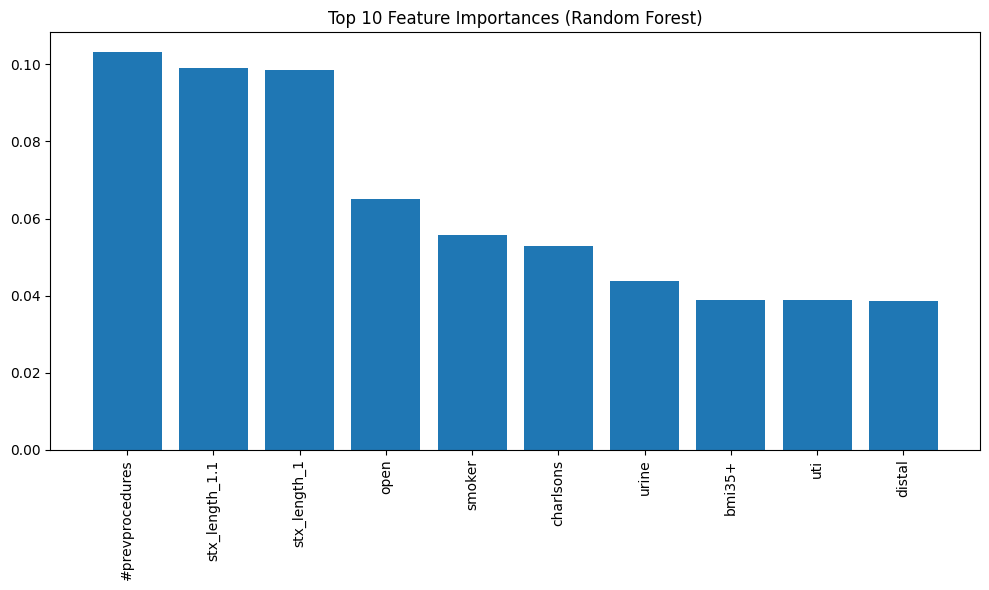

#prevprocedures: 0.10318034234130581
stx_length_1.1: 0.09919440582228954
stx_length_1: 0.09868953584212474
open: 0.06500944174942684
smoker: 0.05583432737257054
charlsons: 0.05283026263283629
urine: 0.043662159939190336
bmi35+: 0.038943920302299394
uti: 0.038758724525113385
distal: 0.038567244358773525


In [220]:
#Plot the top 10 most important features
plt.figure(figsize=(10, 6))
plt.title("Top 10 Feature Importances (Random Forest)")
plt.bar(range(10), importances[indices][:10], align="center")
plt.xticks(range(10), [feature_names[i] for i in indices][:10], rotation=90)
plt.tight_layout()
plt.show()

for i in range(10):
    print(f"{feature_names[indices[i]]}: {importances[indices[i]]}")
